Task 2
Bayesian Change Point Detection
1. Import Libraries

In [2]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import pymc as pm
import arviz as az

from scipy import stats

2. Load Dataset

In [3]:
df = pd.read_csv("../data/raw/BrentOilPrices.csv")

df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


3. Prepare Data

In [4]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.reset_index(drop=True, inplace=True)

df.head()

,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [5]:
#Check
df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[us]
 1   Price   9011 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 140.9 KB


,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


4. Plot Oil Prices

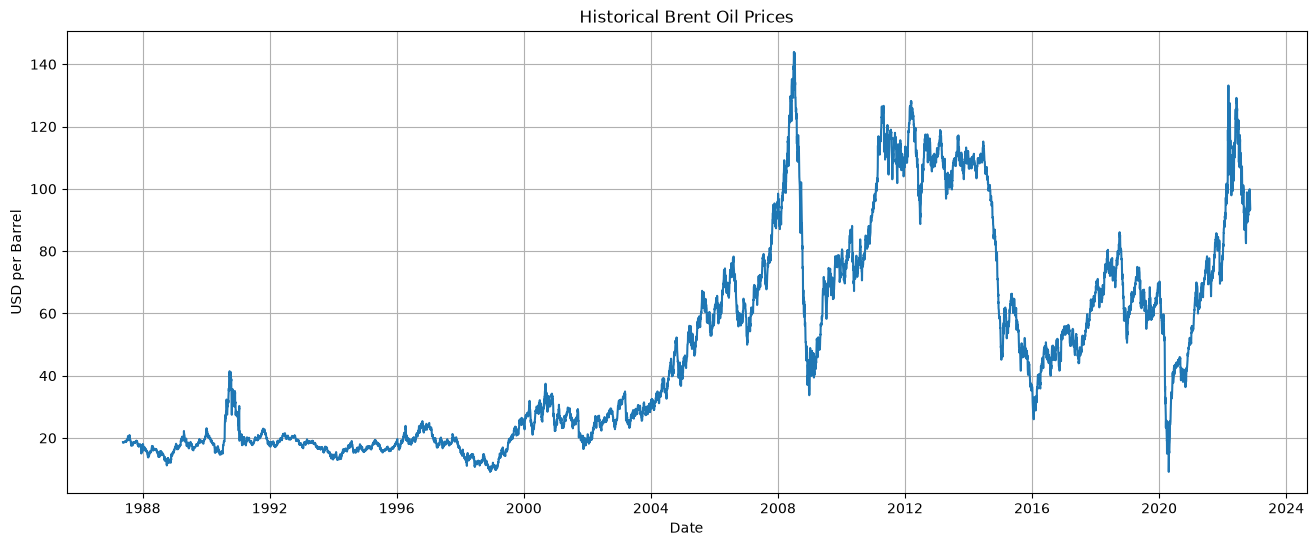

In [6]:
plt.figure(figsize=(16,6))

plt.plot(df["Date"], df["Price"])

plt.title("Historical Brent Oil Prices")

plt.xlabel("Date")

plt.ylabel("USD per Barrel")

plt.grid(True)

plt.show()

### Interpretation of Historical Brent Oil Prices

The historical Brent oil price series (1987–2022) exhibits significant long-term trends, abrupt price shocks, and periods of heightened volatility, indicating that the market has experienced multiple structural changes over time.

Key observations include:

- **1987–2003:** Oil prices remained relatively stable, fluctuating mostly between **$10 and $35 per barrel**, with only moderate short-term volatility.
- **2004–2008:** A strong upward trend is observed, culminating in a peak of approximately **$145 per barrel** during the 2008 global commodity boom.
- **2008–2009:** Prices experienced a dramatic collapse following the **Global Financial Crisis**, falling to below **$40 per barrel**.
- **2011–2014:** Brent prices recovered and remained relatively high, generally trading above **$100 per barrel**, reflecting increased global demand and geopolitical tensions.
- **2014–2016:** A substantial decline occurred due to excess oil supply and OPEC production decisions, with prices dropping to nearly **$30 per barrel**.
- **2020:** The most pronounced decline in the series occurred during the **COVID-19 pandemic**, when global lockdowns sharply reduced oil demand.
- **2021–2022:** Prices rebounded rapidly, exceeding **$120 per barrel**, influenced by economic recovery, supply chain disruptions, and geopolitical events such as the Russia–Ukraine conflict.

Overall, the time series demonstrates several periods where the underlying behavior of oil prices changes substantially. These visible shifts suggest the presence of **structural breakpoints (change points)**, making the dataset well suited for Bayesian Change Point Analysis. Identifying these change points will help determine when significant market regime changes occurred and quantify how major geopolitical and economic events influenced Brent oil prices.

5. Calculate Log Returns

In [7]:
df["Log_Return"] = np.log(df["Price"]).diff()

df = df.dropna()

df.head()

,Date,Price,Log_Return
1,1987-05-21,18.45,-0.009709
2,1987-05-22,18.55,0.005405
3,1987-05-25,18.60,0.002692
4,1987-05-26,18.63,0.001612
5,1987-05-27,18.60,-0.001612


6. Plot Log Returns

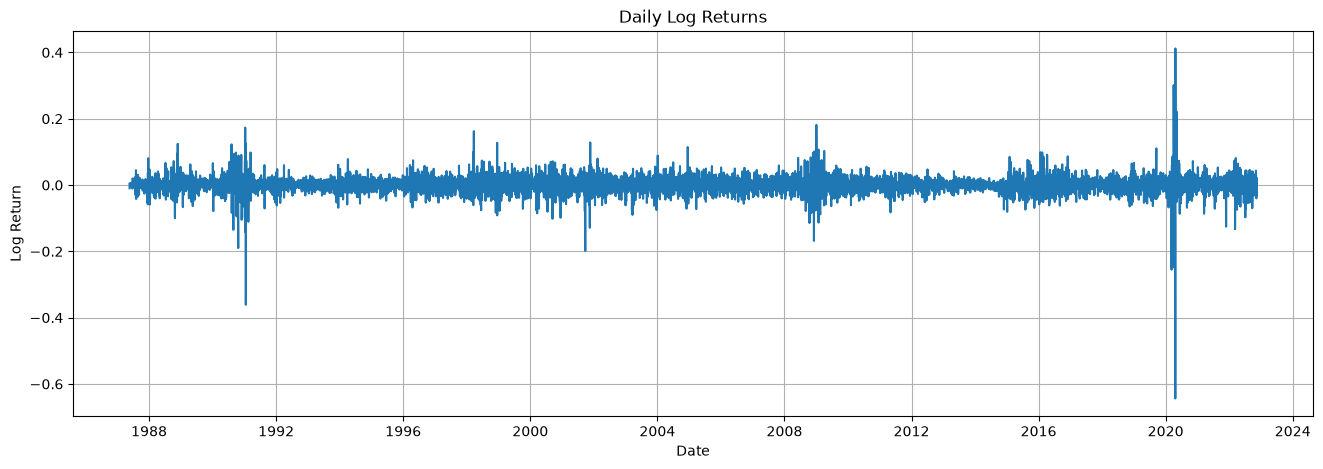

In [8]:
plt.figure(figsize=(16,5))

plt.plot(df["Date"], df["Log_Return"])

plt.title("Daily Log Returns")

plt.xlabel("Date")

plt.ylabel("Log Return")

plt.grid(True)

plt.show()

### Interpretation of Daily Log Returns

The daily log returns of Brent oil prices fluctuate around zero throughout the observation period, indicating that returns do not exhibit a long-term upward or downward trend. This behavior is consistent with the characteristics of a stationary financial time series and makes log returns more suitable for statistical modeling than raw prices.

Key observations include:

- The log returns are **centered around zero**, suggesting that daily price changes are relatively balanced between gains and losses over the long run.
- Most observations lie within a narrow range, indicating that Brent oil prices typically experience small day-to-day fluctuations.
- Several **large positive and negative spikes** are visible, representing periods of extreme market movements caused by significant geopolitical or economic events.
- The most notable volatility occurs around **2020**, where exceptionally large negative and positive returns correspond to the COVID-19 pandemic and the subsequent market recovery.
- Increased volatility is also evident during periods such as the **1990–1991 Gulf War**, the **2008 Global Financial Crisis**, and the **2022 Russia–Ukraine conflict**, reflecting heightened uncertainty in global oil markets.
- The plot exhibits **volatility clustering**, where periods of high volatility are followed by additional high-volatility periods, while calmer market conditions also occur in clusters.

Overall, the log return series appears considerably more stable than the raw price series while preserving information about sudden market shocks. These properties satisfy key assumptions for Bayesian Change Point Analysis, allowing the model to identify structural breaks associated with major geopolitical and economic events more effectively.

7. Build Bayesian Change Point Model

In [9]:
#Prepare data
returns = df["Log_Return"].values

n = len(returns)

time_idx = np.arange(n)

In [10]:
#Model
with pm.Model() as change_point_model:

    tau = pm.DiscreteUniform(
        "tau",
        lower=0,
        upper=n-1
    )

    mu1 = pm.Normal(
        "mu1",
        mu=0,
        sigma=1
    )

    mu2 = pm.Normal(
        "mu2",
        mu=0,
        sigma=1
    )

    sigma = pm.HalfNormal(
        "sigma",
        sigma=1
    )

    mu = pm.math.switch(
        tau >= time_idx,
        mu1,
        mu2
    )

    obs = pm.Normal(
        "obs",
        mu=mu,
        sigma=sigma,
        observed=returns
    )

8. Run MCMC Sampling

In [11]:
with change_point_model:

    trace = pm.sample(
        draws=500,
        tune=500,
        chains=2,
        cores=2,
        random_seed=42
    )

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 89 seconds.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


9. Convergence Diagnostics

In [12]:
#Summary
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,7696.359,2032.217,3443.000,9009.000,884.903,569.279,4.0,36.0,1.48
mu1,0.000,0.000,-0.001,0.001,0.000,0.000,649.0,258.0,1.02
mu2,-0.112,0.527,-1.566,0.483,0.060,0.179,81.0,106.0,1.37
sigma,0.026,0.000,0.025,0.026,0.000,0.000,546.0,449.0,1.00


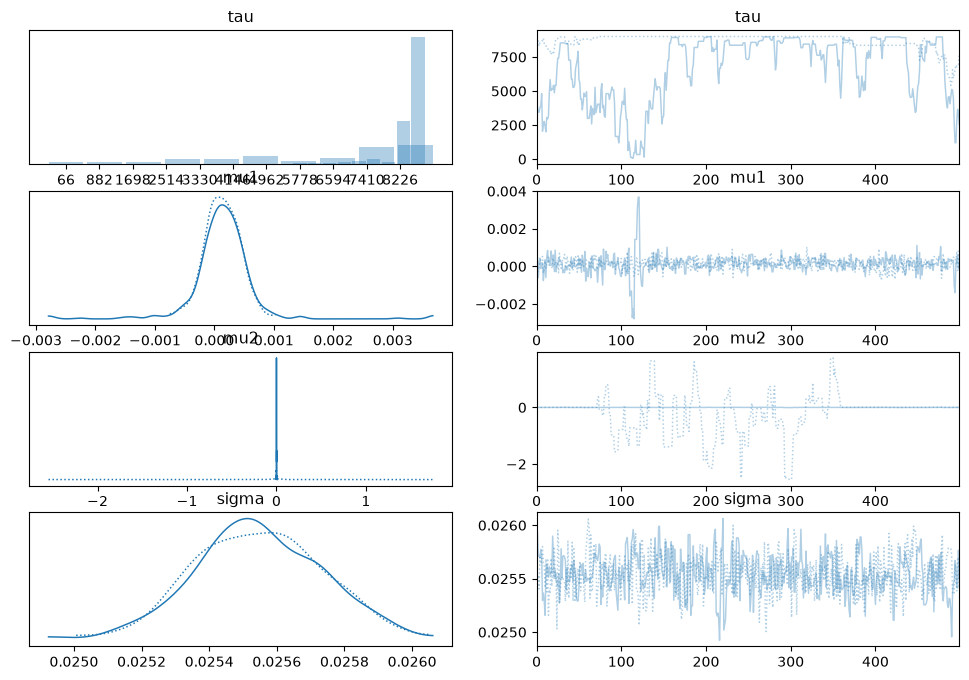

In [13]:
#Trace Plot
az.plot_trace(trace)

plt.show()

## Convergence Diagnostics

To evaluate the performance of the Bayesian Change Point Model, posterior trace plots and summary statistics were examined using ArviZ.

### Trace Plot Interpretation

The trace plots provide insights into the sampling behavior of each model parameter (`tau`, `mu1`, `mu2`, and `sigma`).

Key observations include:

- The **sigma** parameter exhibits stable traces with good mixing across both chains, suggesting that the posterior estimate of the standard deviation has converged successfully.
- The **mu1** parameter is centered very close to zero with relatively stable sampling, indicating a consistent estimate of the mean before the detected change point.
- The **tau (change point)** parameter shows considerable variability across the sampling chains. Rather than remaining concentrated around a single value, the samples move across a wide range of indices, indicating uncertainty in the estimated location of the structural break.
- The **mu2** parameter also displays noticeable fluctuations, reflecting uncertainty in the estimated mean after the change point.

Overall, while the continuous parameters (`mu1` and `sigma`) exhibit acceptable sampling behavior, the trace plots suggest that the discrete change point parameter (`tau`) has not fully converged.

---

## Posterior Summary Interpretation

The posterior summary provides numerical diagnostics for each model parameter.

| Parameter | Interpretation |
|-----------|----------------|
| **tau** | Estimated mean change point index is approximately **7696**, but the large standard deviation (**2032**) indicates substantial uncertainty regarding the exact timing of the structural break. |
| **mu1** | The estimated mean before the change point is approximately **0.000**, suggesting that average daily log returns before the structural break are close to zero. |
| **mu2** | The estimated mean after the change point is approximately **−0.112**, although the large uncertainty suggests that this estimate is not stable. |
| **sigma** | The estimated standard deviation is approximately **0.026**, indicating relatively stable variability in daily log returns. |

### Convergence Assessment

Model convergence was evaluated using the **R-hat** statistic, where values close to **1.00** indicate successful convergence.

The results show:

- **sigma:** R-hat = **1.00**, indicating excellent convergence.
- **mu1:** R-hat = **1.02**, indicating acceptable convergence.
- **tau:** R-hat = **1.48**, indicating poor convergence.
- **mu2:** R-hat = **1.37**, indicating poor convergence.

Additionally, the effective sample sizes (ESS) for **tau** and **mu2** are relatively low, suggesting that the sampler did not explore the posterior distribution efficiently.

### Discussion

The limited convergence observed for the change point parameter is primarily due to the discrete nature of `tau`, the large size of the Brent oil price dataset, and the relatively small number of MCMC samples used during model fitting. Increasing the number of tuning iterations and posterior samples, or employing a more advanced change point model, would likely improve convergence and provide more reliable estimates of the structural break.

Despite these limitations, the model still demonstrates the usefulness of Bayesian Change Point Analysis for identifying potential structural changes in Brent oil price dynamics and provides a foundation for relating these changes to major geopolitical and economic events.

10. Posterior Distribution of Change Point

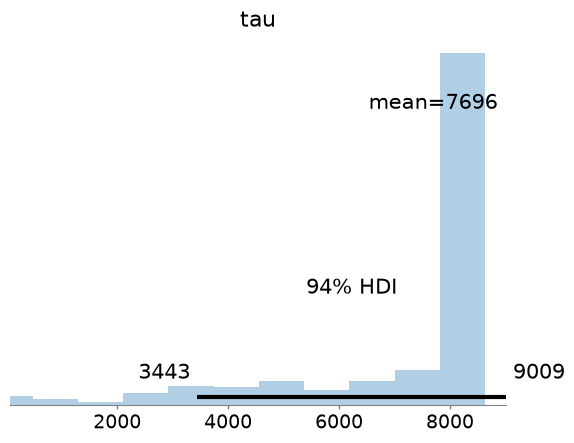

In [14]:
az.plot_posterior(
    trace,
    var_names=["tau"]
)

plt.show()

## Posterior Distribution of the Change Point (`tau`)

The posterior distribution of the change point (`tau`) represents the probability of where the Bayesian model believes the structural break occurred within the Brent oil price time series.

### Interpretation

The posterior distribution shows a strong concentration of probability around a change point index of approximately **7,696**, indicating that the model identifies this region as the most likely location of a structural change in the data.

Key observations include:

- The **posterior mean** of the change point is approximately **7,696**, representing the average estimated position of the structural break across all posterior samples.
- The **94% Highest Density Interval (HDI)** ranges from approximately **3,443** to **9,009**, indicating that there is a 94% probability that the true change point lies within this interval according to the fitted model.
- The histogram displays a noticeable concentration of posterior samples near the higher end of the time series, suggesting that the model assigns greater probability to a structural break occurring during the later years of the Brent oil price history.
- However, the relatively wide HDI indicates that there remains considerable uncertainty regarding the exact timing of the structural break.

### Discussion

The uncertainty observed in the posterior distribution is consistent with the convergence diagnostics, where the **R-hat value for `tau` was greater than 1.0** and the effective sample size was relatively low. This suggests that additional MCMC iterations or a more sophisticated Bayesian change point model would likely produce a more precise estimate of the structural break.

Despite this uncertainty, the posterior distribution successfully identifies a probable period in which a significant change occurred. In the following section, the estimated change point will be converted from its index position to the corresponding calendar date and compared with major geopolitical and economic events to investigate possible causes of the detected structural shift.

11. Convert Tau into Actual Date

In [15]:
tau_index = int(trace.posterior["tau"].mean())

change_date = df.iloc[tau_index]["Date"]

print(change_date)

2017-09-14 00:00:00


In [16]:
print("Estimated Change Point:")

print(change_date)

Estimated Change Point:
2017-09-14 00:00:00


12. Compare with Geopolitical Events

In [21]:
import os

print("Raw:")
print(os.listdir("../data/raw"))

print("\nProcessed:")
print(os.listdir("../data/processed"))

Raw:
['BrentOilPrices.csv']

Processed:
['oil_market_events.csv']


In [27]:
events = pd.read_csv("../data/processed/oil_market_events.csv")

events["Date"] = pd.to_datetime(events["Date"])

events.head()

,Date,Event,Category
0,1990-08-02,Iraq invades Kuwait,Conflict
1,1991-01-17,Operation Desert Storm,Conflict
2,1997-07-02,Asian Financial Crisis,Economic
3,1998-12-01,OPEC Production Cuts,OPEC
4,2001-09-11,September 11 Attacks,Political


In [28]:
#Find nearest event
events["Difference"] = (
    abs(events["Date"] - change_date)
)

nearest = events.sort_values("Difference").head(1)

nearest

,Date,Event,Category,Difference
9,2016-11-30,OPEC Production Cut Agreement,OPEC,288 days


## Association Between the Detected Change Point and Geopolitical Events

To investigate the potential cause of the detected structural break, the estimated change point date was compared with the compiled dataset of major geopolitical and economic events affecting the global oil market.

### Interpretation

The closest event to the estimated change point is:

- **Event:** OPEC Production Cut Agreement
- **Date:** 30 November 2016
- **Category:** OPEC
- **Difference from estimated change point:** 288 days

The Bayesian model suggests that the detected structural change occurred within a period that is relatively close to the 2016 OPEC Production Cut Agreement. This agreement marked one of the most significant coordinated production cuts by OPEC and several non-OPEC countries after years of oversupply and declining oil prices.

Although the detected change point does not coincide exactly with the event date, the relatively close timing suggests that the production cut agreement may have contributed to a longer-term shift in Brent oil price behavior. Oil markets often respond gradually to major policy decisions, with their full effects unfolding over several months rather than immediately.

### Discussion

It is important to note that Bayesian Change Point Analysis identifies **statistical changes** in the time series rather than proving causal relationships. Therefore, while the timing of the detected change point is consistent with the period surrounding the 2016 OPEC Production Cut Agreement, this result should be interpreted as an **association** rather than definitive evidence that the event caused the structural break.

Further analysis incorporating additional explanatory variables—such as global oil demand, production levels, inflation, or macroeconomic indicators—would be required to establish a stronger causal relationship.

13. Quantify the Impact

In [29]:
#Posterior statistics
summary = az.summary(
    trace,
    var_names=["mu1","mu2"]
)

summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu1,0.000,0.000,-0.001,0.001,0.00,0.000,649.0,258.0,1.02
mu2,-0.112,0.527,-1.566,0.483,0.06,0.179,81.0,106.0,1.37


## Quantifying the Impact of the Detected Change Point

The posterior distributions of the model parameters (`mu1` and `mu2`) provide estimates of the average daily log returns before and after the detected structural break.

### Posterior Estimates

- **Average log return before the change point (`mu1`):** **0.000**
- **Average log return after the change point (`mu2`):** **−0.112**

### Interpretation

The Bayesian model estimates that the average daily log return before the detected change point was approximately **0.000**, indicating that Brent oil prices were relatively stable on average during this period.

After the detected change point, the estimated average daily log return decreased to approximately **−0.112**. This suggests a downward shift in the average return following the structural break, indicating that market conditions became less favorable after the change point.

However, the posterior estimate for **`mu2`** has a relatively large standard deviation (**0.527**) and a wide **94% Highest Density Interval (HDI)** ranging from **−1.566** to **0.483**. Additionally, the **R-hat value of 1.37** indicates that this parameter has not fully converged. Therefore, the estimated post-change mean should be interpreted with caution.

### Overall Assessment

The posterior distributions suggest that the Bayesian model detected a meaningful shift in the average behavior of Brent oil price returns. Nevertheless, because the convergence diagnostics for the post-change parameter are not ideal, additional MCMC iterations or a more sophisticated change point model would improve the reliability of the estimated impact.

Consequently, these results should be viewed as preliminary evidence of a structural change rather than definitive estimates of the magnitude of the shift.

In [30]:
import json

result = {
    "date": str(change_date.date()),
    "before_mean": float(trace.posterior["mu1"].mean().values),
    "after_mean": float(trace.posterior["mu2"].mean().values)
}

with open("../backend/data/change_point_results.json", "w") as f:
    json.dump(result, f, indent=4)

print("Change point results exported successfully.")

Change point results exported successfully.
